<a href="https://colab.research.google.com/github/hungryakira/Housing-price-prediction/blob/main/Multivariable_Regression_and_Valuation_Model_(git).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<img src=https://i.imgur.com/WKQ0nH2.jpg height=350>

# Setup and Context


### Introduction

A real estate company in 1970s wants to value any residential project before they start. This exercise aim to build a model that can provide a price estimate based on a home's characteristics like:
* The number of rooms
* The distance to employment centres
* How rich or poor the area is
* How many students there are per teacher in local schools etc

To accomplish this task:

1. Analyse and explore the Boston house price data
2. Split your data for training and testing
3. Run a Multivariable Regression
4. Evaluate how your model's coefficients and residuals
5. Use data transformation to improve your model performance
6. Use your model to estimate a property price

In [ ]:
%pip install --upgrade plotly

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.8/14.8 MB 58.5 MB/s eta 0:00:00
  Attempting uninstall: plotly
    Found existing installation: plotly 5.24.1
    Uninstalling plotly-5.24.1:
      Successfully uninstalled plotly-5.24.1


###  Import Statements


In [ ]:
import pandas as pd
import numpy as np

import seaborn as sns
import plotly.express as px
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression

### Decimal formatting

In [ ]:
pd.options.display.float_format = '{:,.2f}'.format

# Load the Data



In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
data = pd.read_csv('/content/drive/MyDrive/d81/boston.csv', index_col=0)

### Understand the Boston House Price Dataset

---------------------------

**Characteristics:**  

    :Number of Instances: 506

    :Number of Attributes: 13 numeric/categorical predictive. The Median Value (attribute 14) is the target.

    :Attribute Information (in order):
        1. CRIM     per capita crime rate by town
        2. ZN       proportion of residential land zoned for lots over 25,000 sq.ft.
        3. INDUS    proportion of non-retail business acres per town
        4. CHAS     Charles River dummy variable (= 1 if tract bounds river; 0 otherwise)
        5. NOX      nitric oxides concentration (parts per 10 million)
        6. RM       average number of rooms per dwelling
        7. AGE      proportion of owner-occupied units built prior to 1940
        8. DIS      weighted distances to five Boston employment centres
        9. RAD      index of accessibility to radial highways
        10. TAX      full-value property-tax rate per $10,000
        11. PTRATIO  pupil-teacher ratio by town
        12. B        1000(Bk - 0.63)^2 where Bk is the proportion of blacks by town
        13. LSTAT    % lower status of the population
        14. PRICE     Median value of owner-occupied homes in $1000's
        
    :Missing Attribute Values: None

    :Creator: Harrison, D. and Rubinfeld, D.L.

This is a copy of [UCI ML housing dataset](https://archive.ics.uci.edu/ml/machine-learning-databases/housing/). This dataset was taken from the StatLib library which is maintained at Carnegie Mellon University. You can find the [original research paper here](https://deepblue.lib.umich.edu/bitstream/handle/2027.42/22636/0000186.pdf?sequence=1&isAllowed=y).


# Preliminary Data Exploration

* What is the shape of `data`?
* How many rows and columns does it have?
* What are the column names?
* Are there any NaN values or duplicates?

In [ ]:
data.shape

(506, 14)

In [ ]:
data.columns

Index(['CRIM', 'ZN', 'INDUS', 'CHAS', 'NOX', 'RM', 'AGE', 'DIS', 'RAD', 'TAX',
       'PTRATIO', 'B', 'LSTAT', 'PRICE'],
      dtype='object')

## Data Cleaning - Check for Missing Values and Duplicates

In [ ]:
data.isna().any()

,0
CRIM,False
ZN,False
INDUS,False
CHAS,False
NOX,False
RM,False
AGE,False
DIS,False
RAD,False
TAX,False


In [ ]:
data.duplicated().values.any()

np.False_

## Descriptive Statistics


* How many students are there per teacher on average?
* What is the average price of a home in the dataset?
* What are the minimum and the maximum value of the `CHAS` and why?
* What is the maximum and the minimum number of rooms per dwelling in the dataset?

In [ ]:
print(f"On average there are {round(data['PTRATIO'].mean(),0)} student per teacher")
print(f"The average price of a home in this dataset is ${round(data['PRICE'].mean(),1)}K")

On average there are 18.0 student per teacher
The average price of a home in this dataset is $22.5K


In [ ]:
print(f"The highest number of rooms per dwelling in this dataset is {round(data['RM'].max(),0)}. The lowest number of rooms in this data set is {round(data['RM'].min(),0)}")

The max number of rooms per dwelling in this dataset is 9.0. The min number of rooms in this data set is 4.0


## Visualise the Features

Visualise the data for your model. Use Seaborn's displot() to create a bar chart and superimpose the Kernel Density Estimate (KDE) for the following variables:
* PRICE: The home price in thousands.
* RM: the average number of rooms per owner unit.
* DIS: the weighted distance to the 5 Boston employment centres i.e., the estimated length of the commute.
* RAD: the index of accessibility to highways.



#### House Prices

Text(13.819444444444445, 0.5, 'Nbr of Homes')

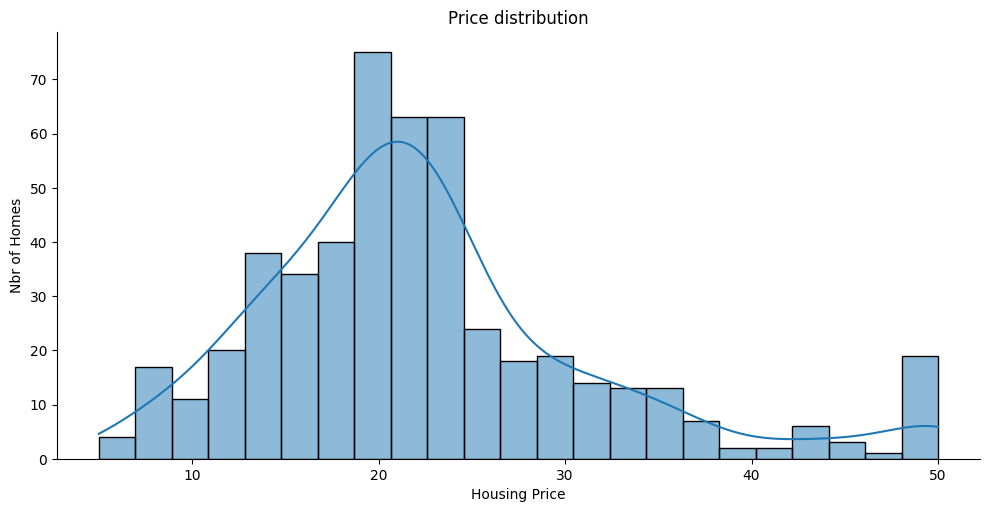

In [ ]:
p1 = sns.displot(data=data, x='PRICE', kde=True, aspect = 2 )
plt.title("Price distribution")
plt.xlabel("Housing Price")
plt.ylabel("Nbr of Homes")

#There is a right skewed distribution for pricing

#### Distance to Employment - Length of Commute

Text(5.069444444444445, 0.5, 'Nbr of Homes')

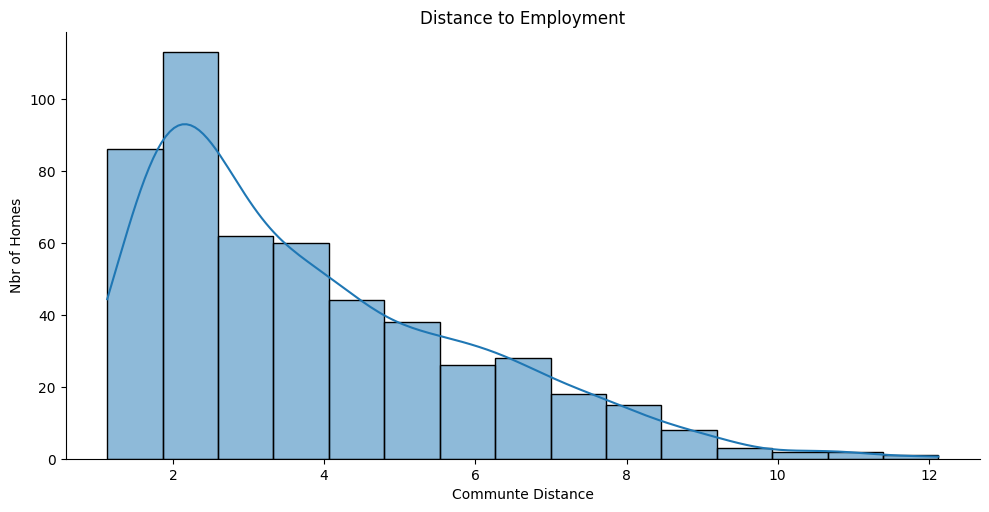

In [ ]:
sns.displot(data=data, x='DIS', kde=True, aspect = 2)
plt.title("Distance to Employment")
plt.xlabel("Communte Distance")
plt.ylabel("Nbr of Homes")
#The strong left skew shows housing are usually quite close to employment center

#### Number of Rooms

Looking at the rooms distribution, we can see that dwellings usually have about 6 rooms
US housing includes living,dining,kitchen in counting rooms. In HK terms, generally 1970s Boston housing has 3-4 bedrooms


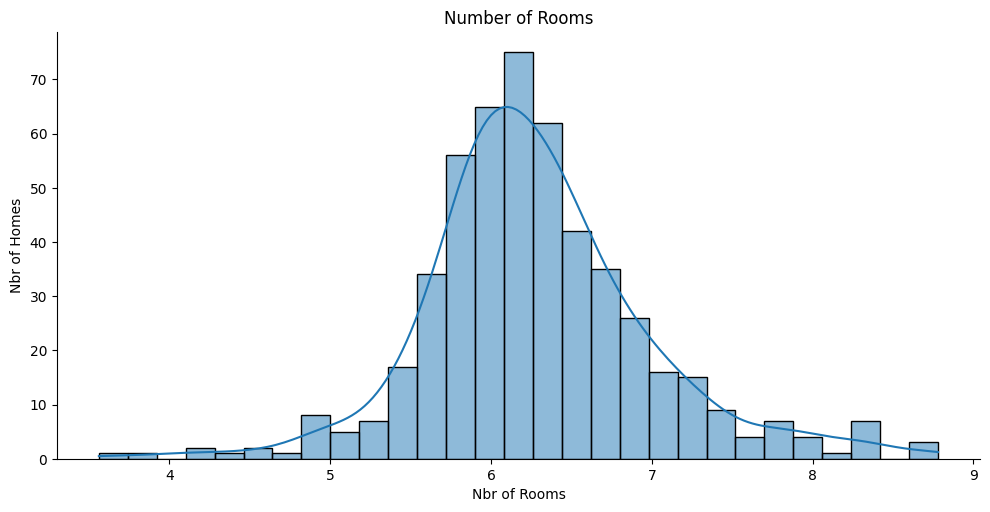

In [ ]:
sns.displot(data=data, x='RM', kde=True, aspect = 2)
plt.title("Number of Rooms")
plt.xlabel("Nbr of Rooms")
plt.ylabel("Nbr of Homes")

print("Looking at the rooms distribution, we can see that dwellings usually have about 6 rooms")
print("US housing includes living,dining,kitchen in counting rooms. In HK terms, generally 1970s Boston housing has 3-4 bedrooms")

#### Access to Highways

currently, most of the housing are very accessible to highways


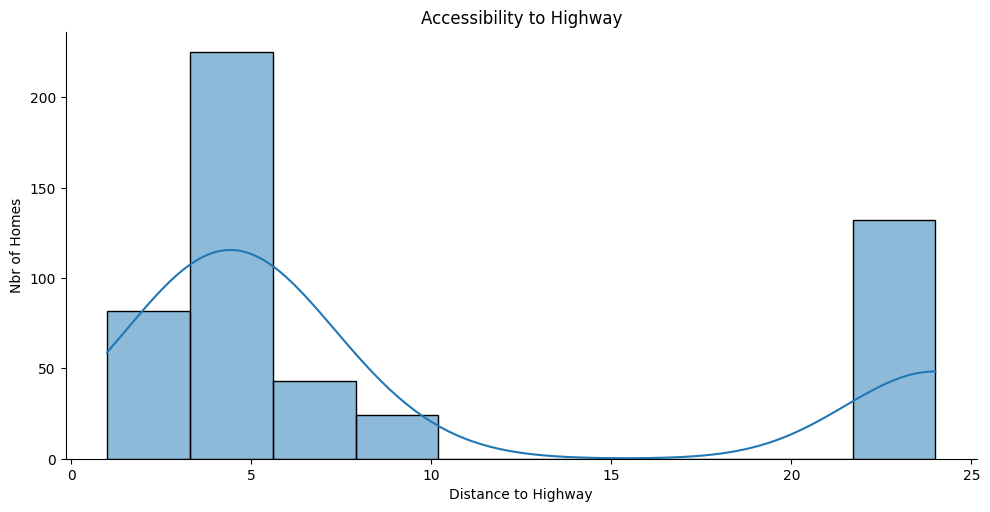

In [ ]:
sns.displot(data=data, x='RAD', kde=True, aspect = 2)
plt.title("Accessibility to Highway")
plt.xlabel("Distance to Highway")
plt.ylabel("Nbr of Homes")
print("Currently, most of the housing are quite accessible to highways")

#### Next to the River?

Create a bar chart with plotly for CHAS to show many more homes are away from the river versus next to it.

In [ ]:
data_CHAS = data.value_counts("CHAS")

In [ ]:
bar = px.bar(x=["No","Yes"], y= data_CHAS.values,
             color=data_CHAS.values,
             title = "Dwellings located next to Charles River",
             color_continuous_scale="Inferno")
bar.update_layout(xaxis_title = "Property Located Next to the River?",
                  yaxis_title = "Number of Homes",
                  coloraxis_showscale = False)
bar.show()

# Understand the Relationships in the Data

### Run a Pair Plot

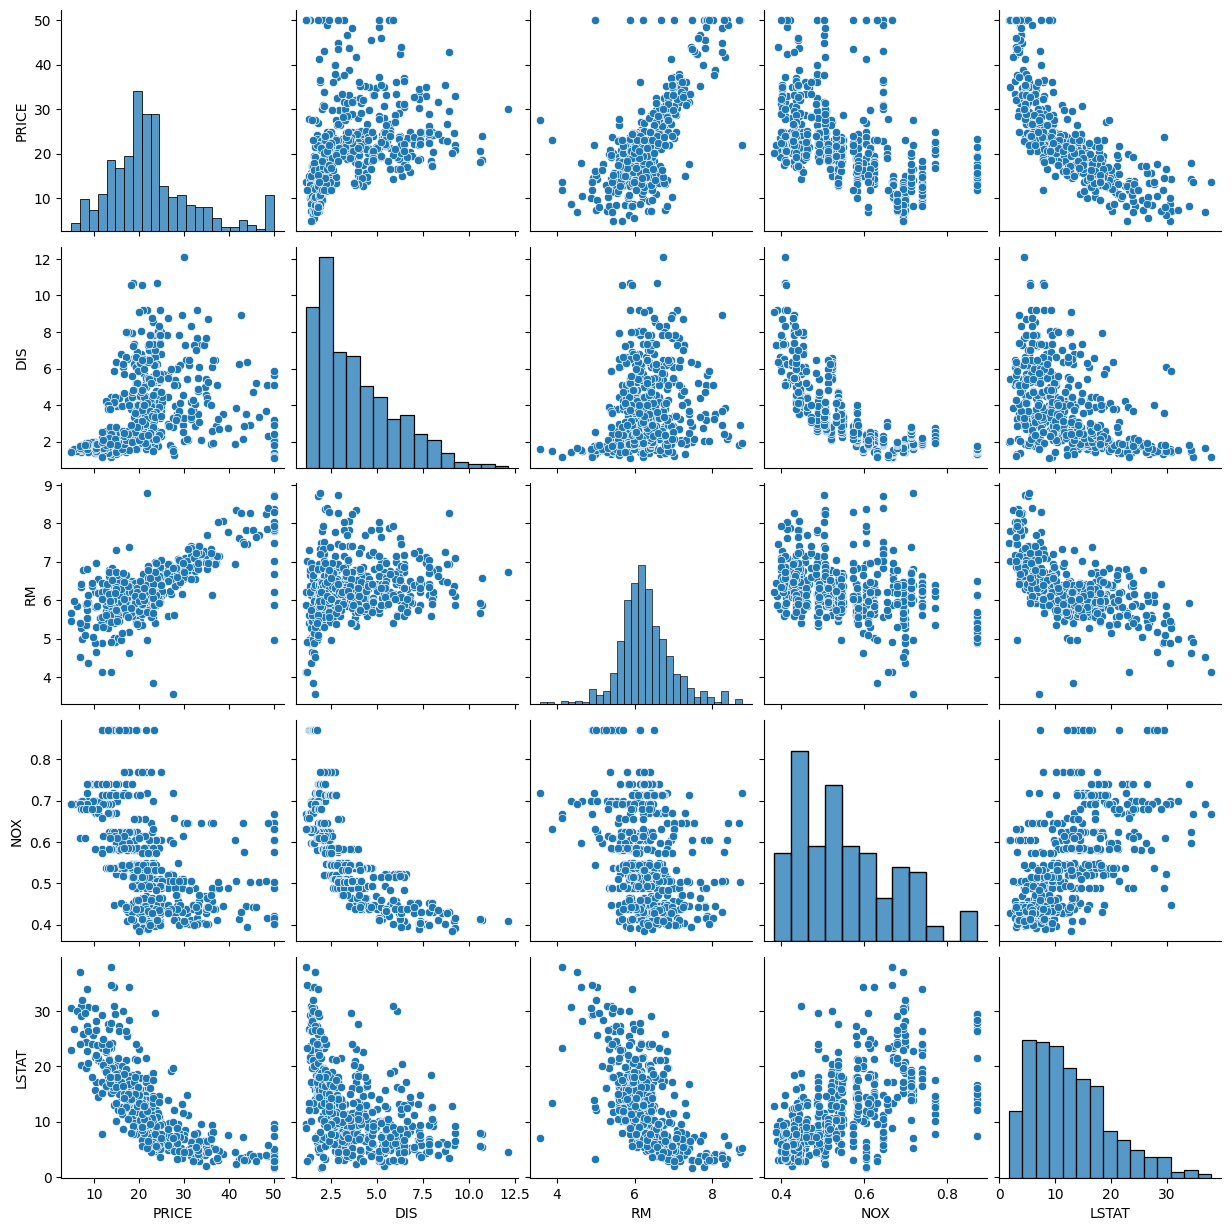

In [ ]:
sns.pairplot(data = data, vars = ["PRICE","DIS","RM","NOX","LSTAT"])

#### Distance from Employment vs. Pollution


Compare DIS (Distance from employment) with NOX (Nitric Oxide Pollution) using Seaborn's `.jointplot()`. Does pollution go up or down as the distance increases?

Pollution decreases as housing is further from employment centers


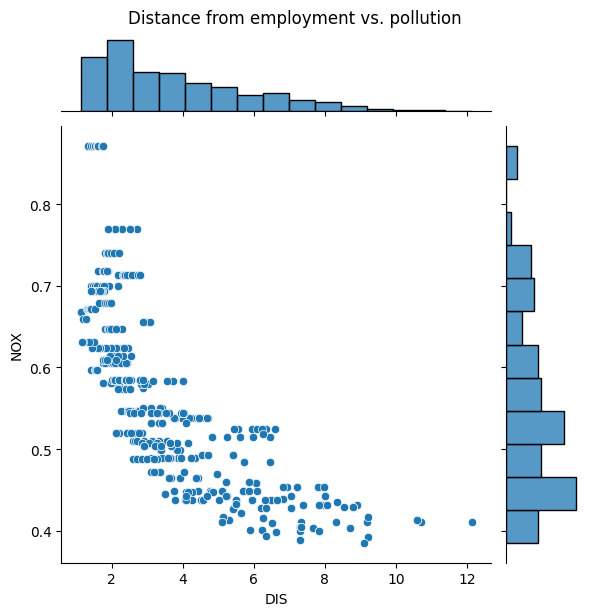

In [ ]:
disnox = sns.jointplot(data = data, x= "DIS", y="NOX")
disnox.fig.suptitle("Distance from employment vs. pollution", y=1.02)

print("Pollution decreases as housing is further from employment centers")

#### Proportion of Non-Retail Industry versus Pollution

Compare INDUS (the proportion of non-retail industry i.e., factories) with NOX (Nitric Oxide Pollution) using Seaborn's `.jointplot()`. Does pollution go up or down as there is a higher proportion of industry?

Pollution increases when an area has more industrial buildings


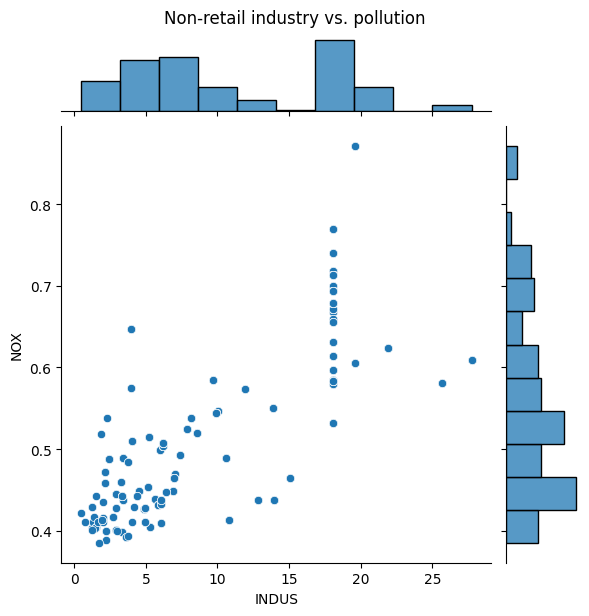

In [ ]:
indusnox = sns.jointplot(data = data, x= "INDUS", y="NOX")
indusnox.fig.suptitle("Non-retail industry vs. pollution", y=1.02)
print("Pollution increases when an area has more industrial buildings")

#### % of Lower Income Population vs Average Number of Rooms

Compare LSTAT (proportion of lower-income population) with RM (number of rooms) using Seaborn's `.jointplot()`.

Homes with less rooms tends to be in high poverty area.


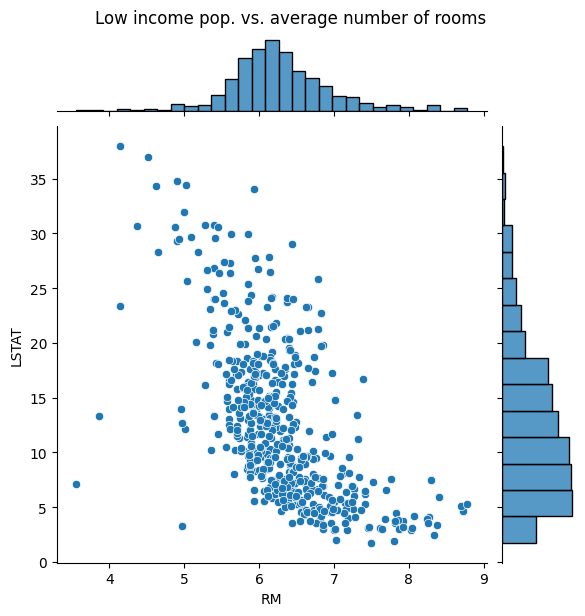

In [ ]:
rmlstat = sns.jointplot(data = data, x= "RM", y="LSTAT")
rmlstat.fig.suptitle("Low income pop. vs. average number of rooms", y=1.02)
print("Homes with less rooms tends to be in high poverty area.")

#### % of Lower Income Population versus Home Price

Compare LSTAT with PRICE using Seaborn's `.jointplot()`. How does the proportion of the lower-income population in an area affect home prices?

As expected, pricy homes are located in areas with low poverty


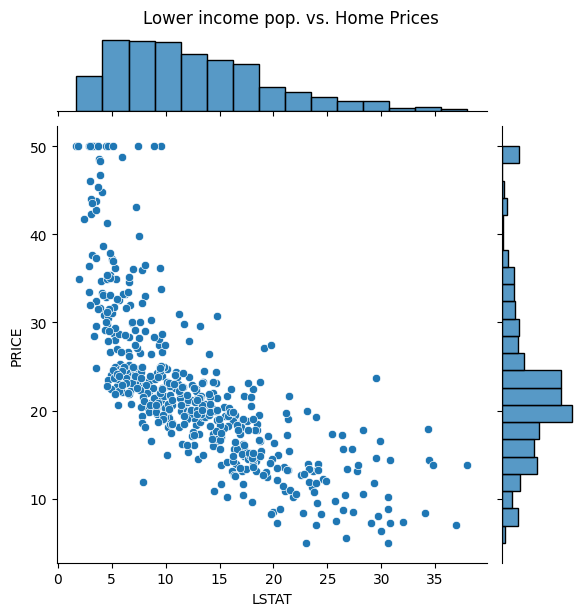

In [ ]:
lstatprice = sns.jointplot(data = data, x= "LSTAT", y="PRICE")
lstatprice.fig.suptitle("Lower income pop. vs. Home Prices", y=1.02)
print("As expected, pricy homes are located in areas with low poverty")

#### Number of Rooms versus Home Value

Compare RM (number of rooms) with PRICE using Seaborn's `.jointplot()

Homes with more rooms strongly correlates with prices


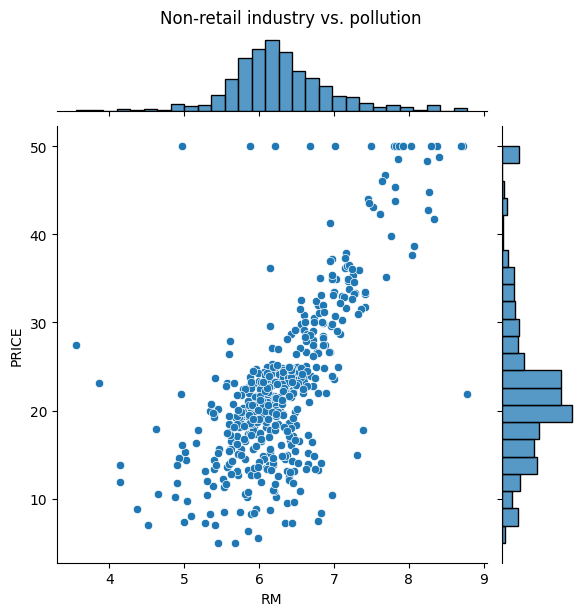

In [ ]:
rmprice=sns.jointplot(data = data, x= "RM", y="PRICE")
rmprice.fig.suptitle("Non-retail industry vs. pollution", y=1.02)
print("Homes with more rooms strongly correlates with prices")

# Split Training & Test Dataset

* Data will be split into 4 subsets: X_train, X_test, y_train, y_test
* The split betweem training and testing data is roughly 80/20.


In [ ]:
from sklearn.model_selection import train_test_split
X = data.drop(columns = "PRICE")
y = data.PRICE
X_train, X_test, y_train, y_test = train_test_split(
    X,y, test_size=0.2, random_state=10)

In [ ]:
# checking % of training set
train_pct = 100*len(X_train)/len(X)
print(f'Training data uses {train_pct:.3}% of the total data.')

# checking % of test data set
test_pct = 100*X_test.shape[0]/X.shape[0]
print(f'Test data makes up the remaining {test_pct:0.3}%.')

Training data uses 79.8% of the total data.
Test data makes up the remaining 20.2%.


# Multivariable Regression

Ther Linear Regression model will have the following form:

$$ PR \hat ICE = \theta _0 + \theta _1 RM + \theta _2 NOX + \theta _3 DIS + \theta _4 CHAS ... + \theta _{13} LSTAT$$

How high is the r-squared for the regression on the training data?

In [ ]:
from sklearn.linear_model import LinearRegression
regression = LinearRegression()
regression.fit(X_train, y_train)
rsquared = regression.score(X_train, y_train)
print(f'The r-squared for the regression of the training data is {rsquared:.2}')

The r-squared for the regression of the training data is 0.75


### Evaluate the Coefficients of the Model

* Based on the coefficients, how much more expensive is a room with 6 rooms compared to a room with 5 rooms? According to the model, what is the premium you would have to pay for an extra room?

In [ ]:
coefficients = pd.DataFrame(data = regression.coef_, index = X_train.columns, columns = ["Coefficient"])
coefficients

,Coefficient
CRIM,-0.13
ZN,0.06
INDUS,-0.01
CHAS,1.97
NOX,-16.27
RM,3.11
AGE,0.02
DIS,-1.48
RAD,0.30
TAX,-0.01


In [ ]:
premium = coefficients.loc['RM'].values[0] * 1000
print(f'Under the current model, the estimated additional cost for having an extra room is ${premium:.5}')

Under the current model, the estimated additional price for having an extra room $3108.5


### Analyse the Estimated Values & Regression Residuals

####The first plot is actual values (`y_train`) against the predicted value values:


In [ ]:
predicted_values = regression.predict(X_train)
residuals = (y_train - predicted_values)

Text(0.5, 1.0, 'Actual Prices vs Predicted Prices')

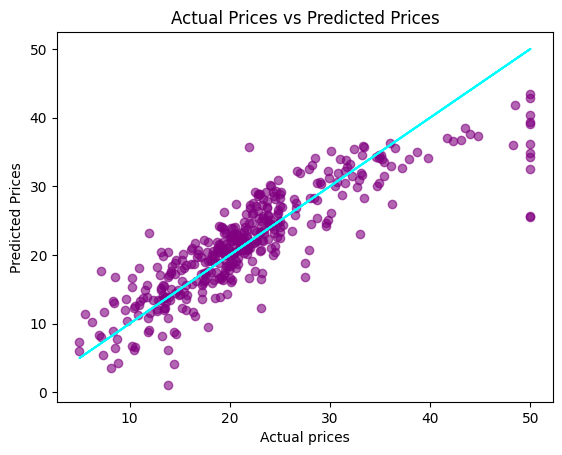

In [ ]:
plt.scatter(x = y_train,
            y = predicted_values,
            color='purple', alpha = 0.6)
plt.plot(y_train, y_train, color = "cyan")
plt.xlabel('Actual prices')
plt.ylabel('Predicted Prices')
plt.title("Actual Prices vs Predicted Prices")

####The second plot is the residuals against the predicted prices.

Text(0.5, 1.0, 'Predicted Prices vs Residuals')

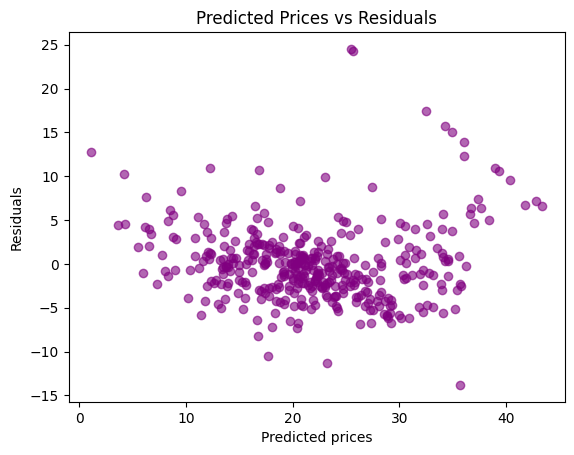

In [ ]:
plt.scatter(x= predicted_values,
            y= residuals,
            color='purple', alpha = 0.6)
plt.xlabel('Predicted prices')
plt.ylabel('Residuals')
plt.title("Predicted Prices vs Residuals")

Examine the distribution of residuals.

* Calculate the mean and the skewness of the residuals.
* Use Seaborn's `.displot()` to create a histogram and superimpose the Kernel Density Estimate (KDE)
* Is the skewness different from zero? If so, by how much?
* Is the mean different from zero?

In [ ]:
#residual distribution
residuals = pd.DataFrame(residuals)
residuals_mean = round(residuals.mean(), 2)
residuals_skew = round(residuals.skew(), 2)
print(f'Residuals skew: {residuals_skew.iloc[0]}, residuals mean:{residuals_mean.iloc[0]}')

print("skew of 1.46 is bit high. Can adjust model to improve")

Residuals skew: 1.46, residuals mean:0.0
skew of 1.46 is bit high. Can adjust model to improve


Text(0.5, 1.0, 'Distribution of Residual values')

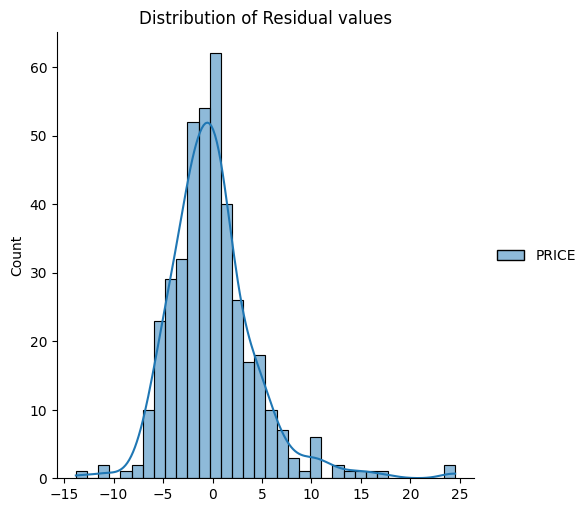

In [ ]:
p1 = sns.displot(residuals, kde=True)
plt.title("Distribution of Residual values")

### Data Transformations for a Better Fit

Transform our data to make it fit better with our linear model.

Investigate if the target `data['PRICE']` could be a suitable candidate for a log transformation.

* Use Seaborn's `.displot()` to show a histogram and KDE of the price data.
* Calculate the skew of that distribution.
* Use NumPy's `log()` function to create a Series that has the log prices
* Plot the log prices using Seaborn's `.displot()` and calculate the skew.
* Which distribution has a skew that's closer to zero?


Text(0.5, 1.0, 'Distribution of Dwelling Prices')

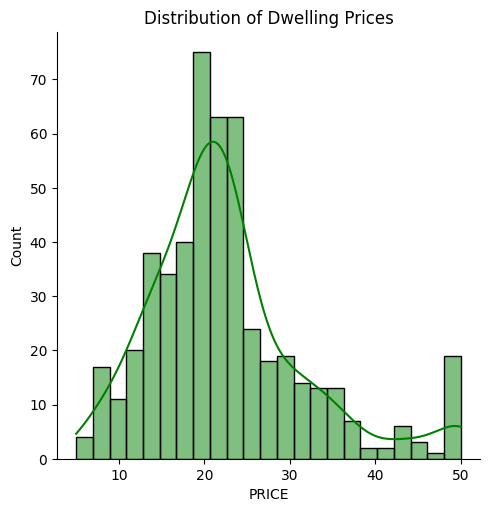

In [ ]:
p1 = sns.displot(data=data, x='PRICE', kde=True, color = 'green')
plt.title("Distribution of Dwelling Prices")

In [ ]:
price_mean = round(data['PRICE'].mean(), 2)
price_skew = round(data['PRICE'].skew(), 2)
print(f'Normal prices skew: {price_skew}, normal price  mean:${price_mean}')

Normal prices skew: 1.11, normal price  mean:$22.53


Text(0.5, 1.0, 'Distribution of log transformed prices')

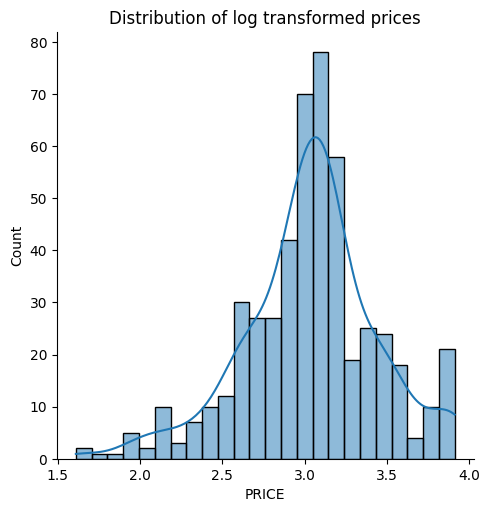

In [ ]:
log_price = np.log(data['PRICE'])
p1 = sns.displot(log_price, kde=True)
plt.title('Distribution of log transformed prices')

#### Log transformation effect on Price Data

Using a log transformation does not affect every price equally. Large prices are affected more than smaller prices in the dataset.

We can see this when we plot the actual prices against the (transformed) log prices.

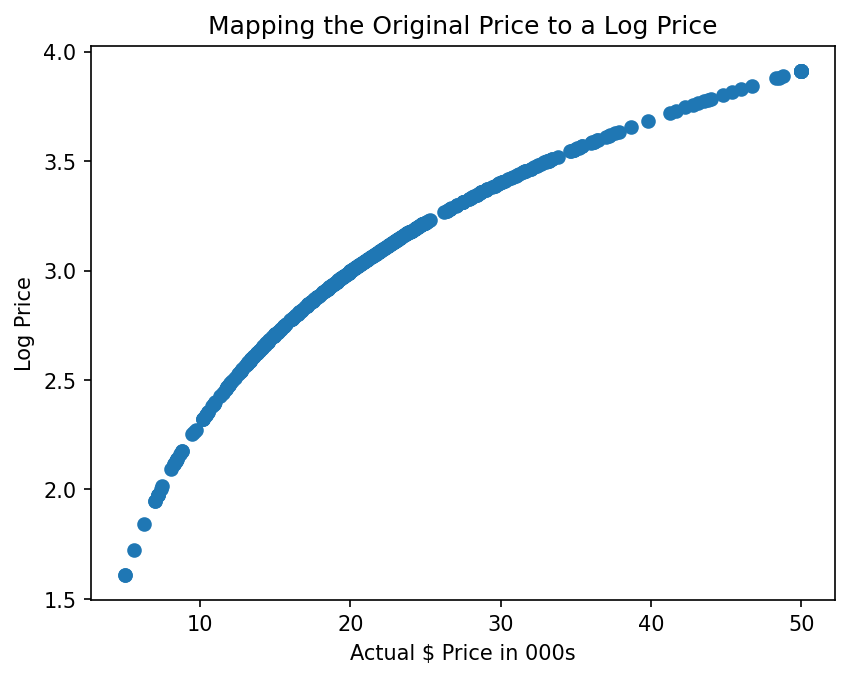

In [ ]:
plt.figure(dpi=150)
plt.scatter(data.PRICE, np.log(data.PRICE))

plt.title('Mapping the Original Price to Log Price')
plt.ylabel('Log Price')
plt.xlabel('Actual $ Price in 000s')
plt.show()

## Regression using Log Prices

Using log prices instead, our model has changed to:

$$ \log (PR \hat ICE) = \theta _0 + \theta _1 RM + \theta _2 NOX + \theta_3 DIS + \theta _4 CHAS + ... + \theta _{13} LSTAT $$


* Use `train_test_split()` with the same random state as before to make the results comparable.
* Run a second regression, but this time use the transformed target data.
* What is the r-squared of the regression on the training data?
* Have we improved the fit of our model compared to before based on this measure?


In [ ]:
log_X = data.drop(columns = "PRICE", axis = 1)
log_y = log_price
log_X_train, log_X_test, log_y_train, log_y_test = train_test_split(
    log_X,log_y, test_size=0.2, random_state=10)

In [ ]:
log_regression = LinearRegression()
log_regression.fit(log_X_train, log_y_train)
log_rsquared = log_regression.score(log_X_train, log_y_train)
print(f'The r-sqaured of the regression on Training data is {log_rsquared:.2}')

The r-sqaured of the regression on Training data is 0.79


## Evaluating Coefficients with Log Prices

*Print out the coefficients of the new regression model.
* Do the coefficients still have the expected sign?
* Is being next to the river a positive based on the data?
* How does the quality of the schools affect property prices? What happens to prices as there are more students per teacher?


In [ ]:
print(f"the Log regression model has intercept: {log_regression.intercept_:.2}")

the Log regression model has: intercept:4.1


In [ ]:
log_coef = pd.DataFrame(log_regression.coef_, index = log_X_train.columns, columns = ["Coefficient"])
log_coef

,Coefficient
CRIM,-0.01
ZN,0.00
INDUS,0.00
CHAS,0.08
NOX,-0.70
RM,0.07
AGE,0.00
DIS,-0.05
RAD,0.01
TAX,-0.00


Being next to the river is a positive factor for housing price.

Having a more students to teachers in school areas has negative impact to housing price


## Regression with Log Prices & Residual Plots

###Compare the regression outcomes with log prices side by side

In [ ]:
log_predicted_values = log_regression.predict(X_train)
log_residuals = (log_y_train - log_predicted_values)

Text(0.5, 1.0, 'Actual Prices vs Predicted Prices(log) (R-Squared 0.79)')

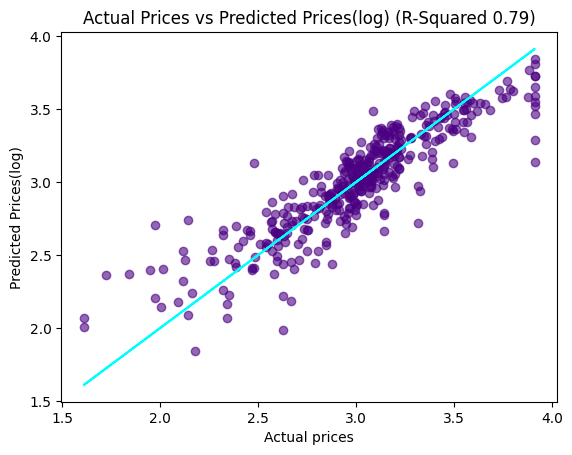

In [ ]:
plt.scatter(x= log_y_train,
            y= log_predicted_values,
            color='indigo', alpha = 0.6)
plt.plot(log_y_train, log_y_train, color = "cyan")
plt.xlabel('Actual prices')
plt.ylabel('Predicted Prices(log)')
plt.title(f"Actual Prices vs Predicted Prices(log) (R-Squared {log_rsquared:.2})")

Text(0.5, 1.0, 'Actual Prices vs Predicted Prices(R-Squared: 0.75)')

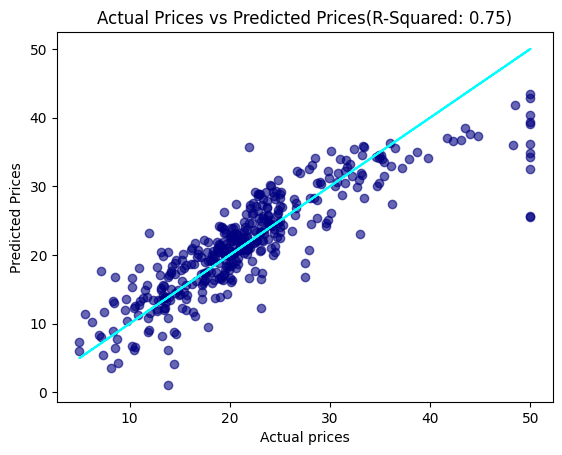

In [ ]:
plt.scatter(x= y_train,
            y= predicted_values,
            color='navy', alpha = 0.6)
plt.plot(y_train, y_train, color = "cyan")
plt.xlabel('Actual prices')
plt.ylabel('Predicted Prices')
plt.title(f"Actual Prices vs Predicted Prices(R-Squared: {rsquared:.2})")

Text(0.5, 1.0, 'Predicted Prices vs Residuals (log)')

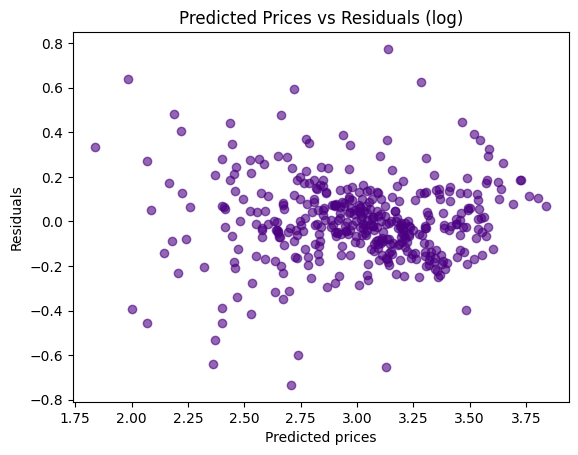

In [ ]:
plt.scatter(x= log_predicted_values,
            y= log_residuals,
            color='indigo', alpha = 0.6)
plt.xlabel('Predicted prices')
plt.ylabel('Residuals')
plt.title("Predicted Prices vs Residuals (log)")

Text(0.5, 1.0, 'Predicted Prices vs Residuals')

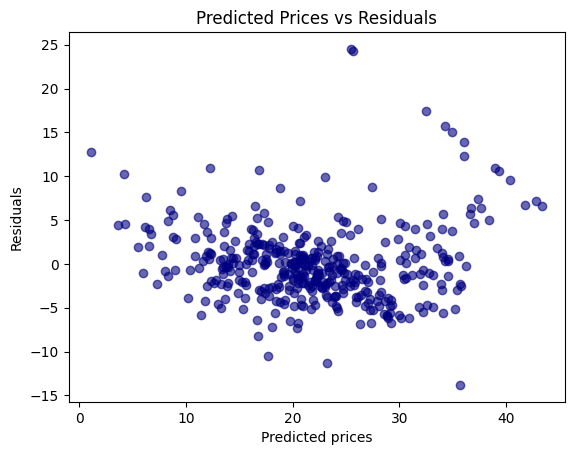

In [ ]:
plt.scatter(x= predicted_values,
            y= residuals,
            color='navy', alpha = 0.6)
plt.xlabel('Predicted prices')
plt.ylabel('Residuals')
plt.title("Predicted Prices vs Residuals")

Calculate the mean and the skew for the residuals using log prices.

Residuals skew: 0.09, residuals mean:-0.0


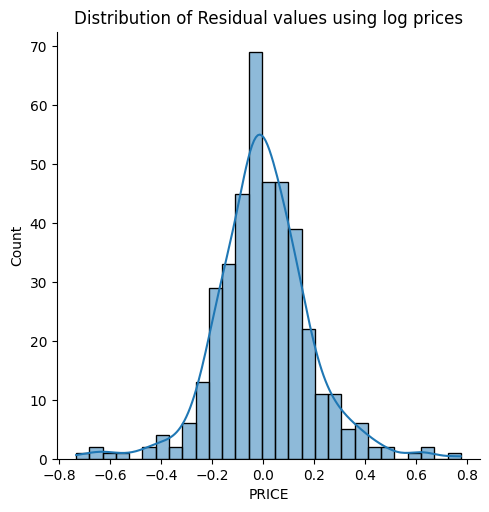

In [ ]:
log_residuals_mean = round(log_residuals.mean(), 2)
log_residuals_skew = round(log_residuals.skew(), 2)

print(f'Residuals skew: {log_residuals_skew}, residuals mean:{log_residuals_mean}')
sns.displot(log_residuals, kde=True)
plt.title("Distribution of Residual values using log prices")
plt.show()

Residuals skew: 1.46, residuals mean:0.0


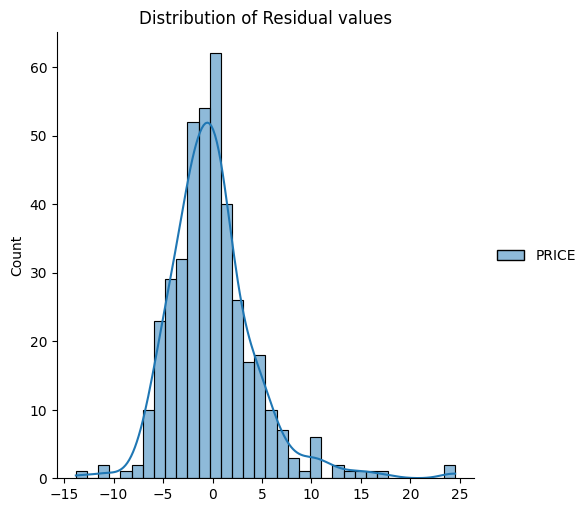

In [ ]:
print(f'Residuals skew: {residuals_skew.iloc[0]}, residuals mean:{residuals_mean.iloc[0]}')

sns.displot(residuals, kde=True)
plt.title("Distribution of Residual values")
plt.show()

New Residual has a skew of 0.09 compared to previous 1.46. Mean is both very close to 0.
In terms of residual and r-square, the new log model is a better fit

# Compare Out of Sample Performance


Compare the r-squared of the two models on the test dataset. Which model does better? Is the r-squared higher or lower than for the training dataset?

In [ ]:
print(f"Original model has r-square of {regression.score(X_test, y_test):.2}")
print(f"New log model has r-square of {log_regression.score(log_X_test, log_y_test):.2}")

Original model has r-square of 0.67
New log model has r-square of 0.74


# Predict a Property's Value using the Regression Coefficients

Our preferred model now has an equation that looks like this:

$$ \log (PR \hat ICE) = \theta _0 + \theta _1 RM + \theta _2 NOX + \theta_3 DIS + \theta _4 CHAS + ... + \theta _{13} LSTAT $$

The average property has the mean value for all its charactistics:

In [ ]:
# Starting Point: Average Values in the Dataset
features = data.drop(['PRICE'], axis=1)
average_vals = features.mean().values
property_stats = pd.DataFrame(data=average_vals.reshape(1, len(features.columns)),
                              columns=features.columns)
property_stats

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT
0,3.61,11.36,11.14,0.07,0.55,6.28,68.57,3.80,9.55,408.24,18.46,356.67,12.65


Predict how much the average property is worth using the stats above. What is the log price estimate and what is the dollar estimate?

.exp() is used to reverse the log transformation with to find the dollar value.

In [ ]:
log_estimate =log_regression.predict(property_stats)[0]
est_price = np.exp(log_estimate)*1000

In [ ]:
print(f"The average price of a property using the log model is: ${est_price:.6}")

The average price of a property using the log model is: $20703.2



Keeping the average values for CRIM, RAD, INDUS and others, value a property with the following characteristics:

In [ ]:
# Define Property Characteristics
next_to_river = True
nr_rooms = 8
students_per_classroom = 20
distance_to_town = 5
pollution = data.NOX.quantile(q=0.75) # high
amount_of_poverty =  data.LSTAT.quantile(q=0.25) # low

In [ ]:
# Solution:

if next_to_river:
  property_stats.CHAS = 0
else:
  property_stats.CHAS = 1

property_stats.RM =nr_rooms
property_stats.PTRATIO=students_per_classroom
property_stats.DIS=distance_to_town
property_stats.NOX=pollution
property_stats.LSTAT=amount_of_poverty

In [ ]:
log_estimate =log_regression.predict(property_stats)[0]
est_price = np.exp(log_estimate)*1000
print(f"The log price is ${log_estimate:.3}")
print(f"The average price of a property using the log model is: ${est_price:.6}")

The log price is $3.17
The average price of a property using the log model is: $23801.2
